# Monotonic effects

When a predictor is **ordered but the spacing between adjacent levels is not meaningful**, the two obvious encodings both lose information:

* Treating it as numeric forces the effect to be linear in the codes ($0, 1, 2, \ldots$), which is rarely defensible. Bürkner and Charpentier (2020) note that this approach "assumes the ordinal categories to be equidistant, which is clearly an oversimplification."
* Treating it as a regular categorical predictor ignores the ordering and spends $K - 1$ independent dummy coefficients. As the number of categories grows, this becomes expensive and noisy.

Bambi's `mo()` term, ported from the R package [brms](https://paulbuerkner.com/brms/), splits the difference. It enforces monotonicity but lets the *shape* of the step-by-step change be inferred from the data, using just two parameters per term.

The contribution of a monotonic predictor with $K$ levels to the linear predictor at observation $n$ is

$$
\eta_n \;=\; b \cdot D \cdot \sum_{i=1}^{x_n} \zeta_i
$$

with categories coded $0, 1, \ldots, D$ (so $D = K - 1$). The two parameters are:

* $b$, a scalar **slope**. It is the expected average difference between two adjacent categories, and $b \cdot D$ is the total expected difference between the lowest and highest categories.
* $\zeta = (\zeta_1, \ldots, \zeta_D)$, a length-$D$ **simplex** ($\zeta_i \geq 0$, $\sum_i \zeta_i = 1$). Each $\zeta_i$ is the *proportion* of the overall effect allocated to the step from level $i-1$ to level $i$.

The simplex gets a Dirichlet prior. The brms default (used here) is $\zeta \sim \text{Dirichlet}(1, \ldots, 1)$, which is uniform on the simplex and centred around a linear trend.

In this notebook we walk through:

1. A basic main-effect example with an ordered categorical predictor.
2. Why neither numeric nor categorical encoding works as well.
3. Integer-valued monotonic predictors (e.g. Likert items).
4. Customizing the Dirichlet prior on the simplex.
5. Sharing a simplex across `mo()` terms via `id=` (conditional monotonicity).
6. Interactions, like `mo(income) * x`.
7. Group-specific monotonic effects, `(mo(x) | g)`.
8. When `mo()` is not the right tool.

In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

import bambi as bmb
from bambi.interpret import plot_predictions

warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=UserWarning)

rng = np.random.default_rng(seed=1234)

## 1. A basic example

We replicate the brms vignette setup. An ordered factor `income` has four brackets, and the response `ls` (life satisfaction) has bracket means **30, 60, 70, 75**. The relationship is monotonically increasing but the spacing is far from linear in the codes: the jumps from bracket to bracket are 30, 10, 5.

In [2]:
levels = ["below_20", "20_to_40", "40_to_100", "greater_100"]
true_means = {
    "below_20": 30.0,
    "20_to_40": 60.0,
    "40_to_100": 70.0,
    "greater_100": 75.0,
}

n = 400
income = pd.Categorical(
    rng.choice(levels, n), categories=levels, ordered=True
)
ls = np.array([true_means[i] for i in income]) + rng.normal(0, 7, n)
data = pd.DataFrame({"ls": ls, "income": income})

data.head()

,ls,income
0,55.889711,greater_100
1,75.256520,greater_100
2,80.171188,greater_100
3,62.623019,20_to_40
4,25.476075,below_20


Visualize the data. The bracket-by-bracket means highlight the strongly non-linear spacing.

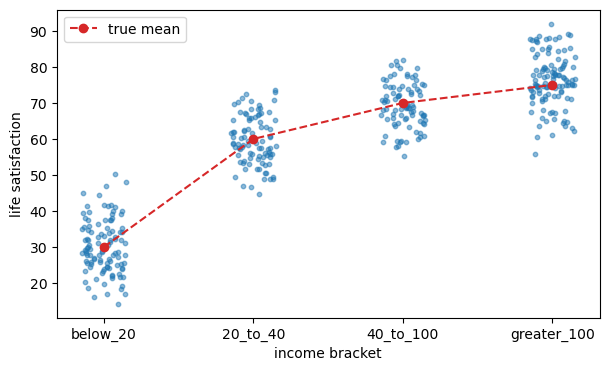

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(
    [levels.index(i) + rng.uniform(-0.15, 0.15) for i in data["income"]],
    data["ls"],
    s=10,
    alpha=0.5,
    color="C0",
)
ax.plot(
    range(len(levels)),
    [true_means[lvl] for lvl in levels],
    color="C3",
    marker="o",
    linestyle="--",
    label="true mean",
)
ax.set_xticks(range(len(levels)))
ax.set_xticklabels(levels)
ax.set_xlabel("income bracket")
ax.set_ylabel("life satisfaction")
ax.legend();

### Fitting the model

`mo()` is a stateful transform inside the model formula. It accepts integer or ordered categorical predictors. Here we let Bambi pick default priors: a `Dirichlet(1, 1, 1)` for the simplex and an auto-scaled Normal for the slope.

In [4]:
model = bmb.Model("ls ~ mo(income)", data)
model

       Formula: ls ~ mo(income)
        Family: gaussian
          Link: mu = identity
  Observations: 400
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 58.7289, sigma: 48.5408)
        
        Monotonic effects
            mo(income)
                simplex ~ Dirichlet(a: [1. 1. 1.])
                slope ~ Normal(mu: 0.0, sigma: 16.1803)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 19.4163)

In [5]:
idata = model.fit(
    draws=1000,
    tune=1000,
    chains=4,
    random_seed=1234,
    progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, mo(income)_simplex, mo(income)_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


The posterior has two new variables: `mo(income)_slope` (the scalar slope) and `mo(income)_simplex` (a length-3 Dirichlet simplex). We split the trace into two calls: scalars in the first, the simplex components in the second.

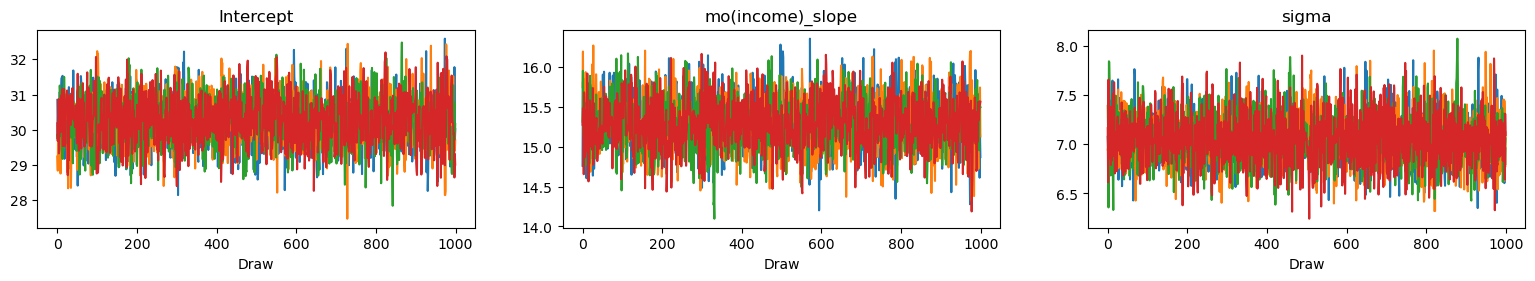

In [6]:
az.plot_trace(
    idata,
    var_names=["Intercept", "mo(income)_slope", "sigma"],
);

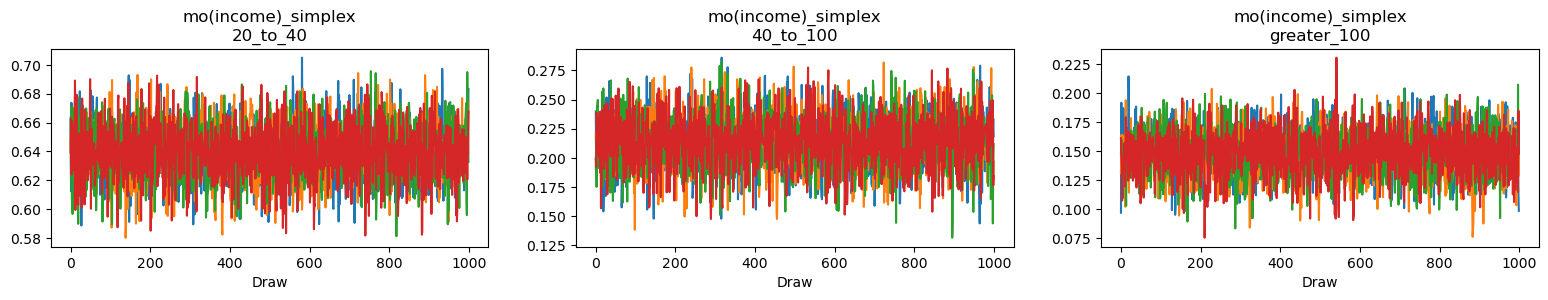

In [7]:
az.plot_trace(idata, var_names=["mo(income)_simplex"]);

In [8]:
az.summary(
    idata,
    var_names=["Intercept", "mo(income)_slope", "mo(income)_simplex", "sigma"],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,30.25,0.68,29,31,3062,2779,1.00,0.012,0.0088
mo(income)_slope,15.3,0.318,15,16,2738,2571,1.00,0.0061,0.0043
mo(income)_simplex[20_to_40],0.6395,0.019,0.61,0.67,4271,2568,1.00,0.00029,0.0002
mo(income)_simplex[40_to_100],0.2129,0.0229,0.18,0.25,4089,2867,1.00,0.00036,0.00025
mo(income)_simplex[greater_100],0.1476,0.02,0.12,0.18,3992,2643,1.00,0.00032,0.00022
sigma,7.047,0.252,6.7,7.5,4579,3031,1.00,0.0038,0.0028


The simplex posterior recovers the unequal spacing of the bracket means. The first step is large (about 0.67 of the total range), the middle moderate (about 0.22), and the last small (about 0.11). The slope `b` lands at the per-step *average* increase, around $(75 - 30) / 3 = 15$.

$b$ and $\zeta$ are easiest to interpret together. Bürkner and Charpentier (2020) recommend reporting the *step magnitudes* $b \cdot D \cdot \zeta_i$, which are the actual posterior estimates of the per-bracket increments on the response scale. The two panels below plot those step magnitudes and the cumulative effect from the baseline level, with two reference points each: the **empirical sample mean** (green circles, what the model is fitting) and the **generative truth** (red squares, the targets we drew the data from). We will unpack what those mean right after the figure.

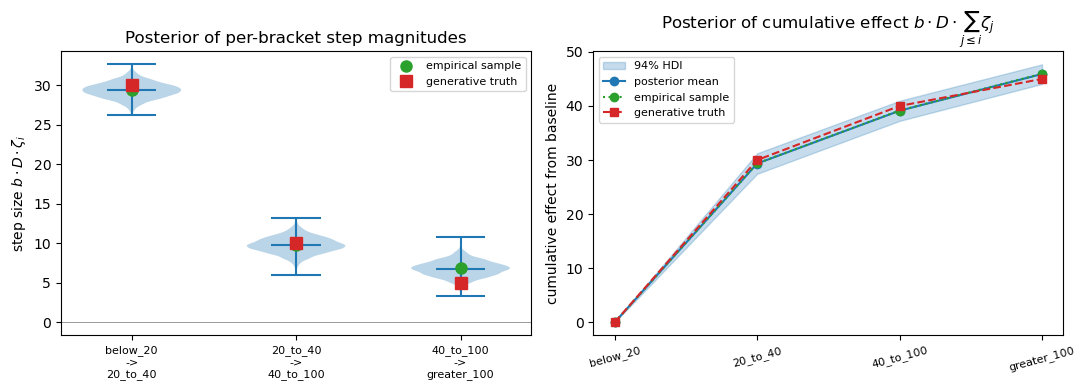

In [9]:
post = idata.posterior
b_draws = post["mo(income)_slope"].stack(s=("chain", "draw")).to_numpy()
zeta_draws = post["mo(income)_simplex"].stack(s=("chain", "draw")).to_numpy()
D = zeta_draws.shape[0]
step_magnitudes = D * b_draws[None, :] * zeta_draws  # (D, draws)
cum_effect = np.concatenate(
    [np.zeros((1, step_magnitudes.shape[1])), np.cumsum(step_magnitudes, axis=0)],
    axis=0,
)  # (D+1, draws)

# Two reference lines: the generative truth and the empirical sample means.
gen_cum = np.array([true_means[l] - true_means[levels[0]] for l in levels])
gen_steps = np.diff(gen_cum)
emp_means = data.groupby("income", observed=False)["ls"].mean().reindex(levels).to_numpy()
emp_cum = emp_means - emp_means[0]
emp_steps = np.diff(emp_cum)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
positions = np.arange(1, D + 1)
ax.violinplot(step_magnitudes.T, positions=positions, showmeans=True, widths=0.6)
ax.plot(positions, emp_steps, marker="o", linestyle="", color="C2",
        markersize=8, label="empirical sample")
ax.plot(positions, gen_steps, marker="s", linestyle="", color="C3",
        markersize=8, label="generative truth")
ax.set_xticks(positions)
ax.set_xticklabels([f"{a}\n->\n{b}" for a, b in zip(levels[:-1], levels[1:])],
                   fontsize=8)
ax.set_ylabel("step size $b \\cdot D \\cdot \\zeta_i$")
ax.set_title("Posterior of per-bracket step magnitudes")
ax.axhline(0, color="0.6", lw=0.7)
ax.legend(fontsize=8)

ax = axes[1]
mean_cum = cum_effect.mean(axis=1)
lo = np.quantile(cum_effect, 0.03, axis=1)
hi = np.quantile(cum_effect, 0.97, axis=1)
ax.fill_between(np.arange(D + 1), lo, hi, color="C0", alpha=0.25, label="94% HDI")
ax.plot(np.arange(D + 1), mean_cum, marker="o", color="C0", label="posterior mean")
ax.plot(np.arange(D + 1), emp_cum, marker="o", linestyle=":", color="C2",
        label="empirical sample")
ax.plot(np.arange(D + 1), gen_cum, marker="s", linestyle="--", color="C3",
        label="generative truth")
ax.set_xticks(np.arange(D + 1))
ax.set_xticklabels(levels, fontsize=8, rotation=15)
ax.set_ylabel("cumulative effect from baseline")
ax.set_title("Posterior of cumulative effect $b \\cdot D \\cdot \\sum_{j \\leq i} \\zeta_j$")
ax.legend(fontsize=8)
fig.tight_layout();

Walking through the figure:

* The three violins on the left are the posterior of each step size   $b \cdot D \cdot \zeta_i$. The first step is by far the largest,   the middle is moderate, the last is small. The posterior is fairly   tight because we have 400 observations.
* On the right, the cumulative bands show the posterior mean and   94% credible interval for the bracket-to-bracket cumulative effect,   $b \cdot D \cdot \sum_{j \leq i} \zeta_j$, added to the baseline.

Two reference lines appear, and they are not the same:

* **Empirical sample mean.** This is just   `data.groupby("income").mean()` on the noisy 400-row data set we   ended up with. In our run the four bracket means come out to   roughly $\{31.9, 60.0, 68.6, 73.2\}$. The model only ever sees   the data, so its posterior should track these, not the targets we   originally drew from.
* **Generative truth.** Earlier in the notebook we built the   synthetic dataset by taking the means $\{30, 60, 70, 75\}$ for the   four brackets and adding $\mathcal{N}(0, 7)$ noise to each   observation. The generative truth is those four target means.   Because the noise is random and we have only ~100 observations   per bracket, the empirical means come out close to the targets but   not equal to them.

The takeaway: the visible gap between the posterior and the generative truth is not a model bias. The posterior wraps the empirical sample (green) tightly, which is exactly what we want; the remaining offset from the generative targets (red) is the sample noise we ourselves injected when simulating the data. With many more observations per bracket the empirical means would converge to the generative targets and the two reference lines would coincide.

Bürkner and Charpentier note a useful self-regularizing property of this parameterization: "if one particular element of $\zeta$ is large, larger values of other elements are automatically penalized due to the sum-to-one constraint," and "if $b$ is close to 0, the complexity of a monotonic predictor with an effect close to zero naturally reduces to the complexity of a simple linear predictor."

### Reconstructing the bracket means

The fitted mean at bracket $k$ is

$$
\mu_k = \alpha + b \cdot D \cdot \sum_{i=1}^{k} \zeta_i
$$

which is what `Model.predict` returns when we pass one row per bracket.

In [10]:
new_df = pd.DataFrame(
    {"income": pd.Categorical(levels, categories=levels, ordered=True)}
)
preds = model.predict(
    idata, kind="response_params", data=new_df, inplace=False
)
mu_post = preds.posterior["mu"]
fitted_summary = pd.DataFrame(
    {
        "level": levels,
        "true_mean": [true_means[l] for l in levels],
        "fitted_mean": mu_post.mean(("chain", "draw")).to_numpy().round(2),
        "lower_94": mu_post.quantile(0.03, ("chain", "draw")).to_numpy().round(2),
        "upper_94": mu_post.quantile(0.97, ("chain", "draw")).to_numpy().round(2),
    }
)
fitted_summary

,level,true_mean,fitted_mean,lower_94,upper_94
0,below_20,30.0,30.25,28.97,31.52
1,20_to_40,60.0,59.60,58.26,61.01
2,40_to_100,70.0,69.37,68.00,70.73
3,greater_100,75.0,76.15,74.93,77.39


## 2. Comparison with numeric and categorical encodings

Fit two alternative models on the same data:

* `ls ~ income_code` treats the four levels as evenly spaced numbers $0, 1, 2, 3$. This is the most restrictive encoding because it forces a linear effect.
* `ls ~ C(income)` uses three independent dummy coefficients. This is the most flexible encoding: each bracket gets its own mean, but the ordering information is lost.

The monotonic model sits in between: it imposes the ordering constraint but otherwise lets the bracket means take any monotone shape.

In [11]:
data["income_code"] = data["income"].cat.codes.astype(float)

model_num = bmb.Model("ls ~ income_code", data)
idata_num = model_num.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

model_cat = bmb.Model("ls ~ C(income)", data)
idata_cat = model_cat.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, income_code]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, C(income)]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Compare via leave-one-out cross-validation. We expect the monotonic and fully categorical models to be close (the true mean structure satisfies the monotonicity constraint *and* it is unconstrained beyond that). The numeric encoding should lag behind because it cannot represent uneven spacing.

In [12]:
az.compare(
    {"numeric": idata_num, "categorical": idata_cat, "monotonic": idata}
)

,rank,elpd,p,elpd_diff,weight,se,dse,warning
monotonic,0,-1350.0,4.6,0.00,1.0,13.0,0.000,False
categorical,1,-1350.0,4.6,-0.03,0.0,13.0,0.033,False
numeric,2,-1460.0,2.7,-110.00,0.0,13.0,12.000,False


Two patterns to notice. First, the monotonic model usually wins on `elpd_loo` against numeric (which is forced to be linear) and is competitive with categorical. Second, the monotonic model achieves that fit with **two** parameters where the categorical model uses **three**, and the gap grows quickly with $K$: a 10-level Likert item would need 9 dummies but still just 2 parameters with `mo()`. Bürkner and Charpentier emphasize that the monotonic model often wins via *lower `p_loo`* (effective parameters), not necessarily higher raw fit.

Visually:

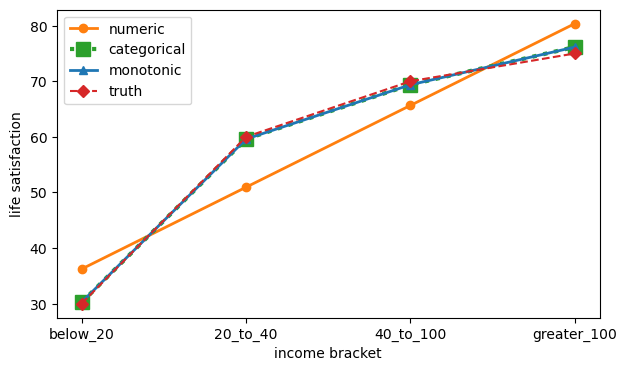

In [13]:
fitted_num = model_num.predict(
    idata_num,
    kind="response_params",
    data=new_df.assign(income_code=np.arange(4, dtype=float)),
    inplace=False,
).posterior["mu"]
fitted_cat = model_cat.predict(
    idata_cat, kind="response_params", data=new_df, inplace=False
).posterior["mu"]

fig, ax = plt.subplots(figsize=(7, 4))
xs = np.arange(len(levels))
ax.plot(xs, fitted_num.mean(("chain", "draw")).to_numpy(),
        color="C1", marker="o", linewidth=2, label="numeric")
ax.plot(xs, fitted_cat.mean(("chain", "draw")).to_numpy(),
        color="C2", marker="s", linestyle=":", linewidth=3,
        markersize=10, label="categorical")
ax.plot(xs, mu_post.mean(("chain", "draw")).to_numpy(),
        color="C0", marker="^", linewidth=2, label="monotonic")
ax.plot(xs, [true_means[lvl] for lvl in levels],
        color="C3", marker="D", linestyle="--", label="truth")
ax.set_xticks(xs)
ax.set_xticklabels(levels)
ax.set_xlabel("income bracket")
ax.set_ylabel("life satisfaction")
ax.legend();

The numeric line is forced to be straight, so it overshoots the lower brackets and undershoots the higher ones. The categorical (dotted, larger markers) and monotonic fits sit on top of each other, but the categorical line is drawn with a dotted style and slightly larger markers so it stays visible behind the monotonic line.

## 3. Integer predictors

`mo()` also accepts integer-valued predictors. Think of Likert-style items or dose levels. The level codes are taken to be the sorted unique integers in the data.

In [14]:
n_int = 300
dose = rng.integers(1, 6, n_int)  # 1, 2, 3, 4, 5
# Doubly non-linear response: small effect at 1->2, then big jumps
effects = np.array([0.0, 1.0, 4.0, 7.0, 8.0])
y_int = 2.0 + effects[dose - 1] + rng.normal(0, 1.0, n_int)
df_int = pd.DataFrame({"y": y_int, "dose": dose})

model_int = bmb.Model("y ~ mo(dose)", df_int)
idata_int = model_int.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False
)

az.summary(
    idata_int,
    var_names=["Intercept", "mo(dose)_slope", "mo(dose)_simplex", "sigma"],
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, mo(dose)_simplex, mo(dose)_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,2.032,0.128,1.8,2.2,1551,1930,1.00,0.0033,0.0023
mo(dose)_slope,1.965,0.046,1.9,2,1648,1767,1.00,0.0011,0.00082
mo(dose)_simplex[2],0.131,0.0223,0.095,0.17,1639,1739,1.00,0.00055,0.00039
mo(dose)_simplex[3],0.3461,0.024,0.31,0.38,2717,2814,1.00,0.00046,0.00033
mo(dose)_simplex[4],0.4284,0.0243,0.39,0.47,3057,2939,1.00,0.00044,0.0003
mo(dose)_simplex[5],0.0948,0.0224,0.059,0.13,2971,1963,1.00,0.00041,0.00027
sigma,1.002,0.041,0.94,1.1,2969,2723,1.00,0.00075,0.00053


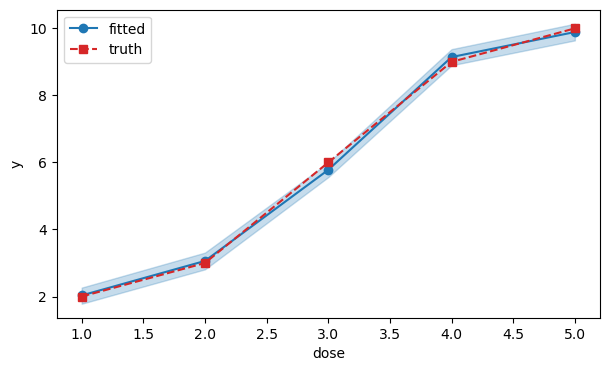

In [15]:
new_doses = pd.DataFrame({"dose": np.arange(1, 6)})
preds_int = model_int.predict(
    idata_int, kind="response_params", data=new_doses, inplace=False
).posterior["mu"]

fig, ax = plt.subplots(figsize=(7, 4))
mu_mean = preds_int.mean(("chain", "draw")).to_numpy()
lo = preds_int.quantile(0.03, ("chain", "draw")).to_numpy()
hi = preds_int.quantile(0.97, ("chain", "draw")).to_numpy()
ax.fill_between(np.arange(1, 6), lo, hi, color="C0", alpha=0.25)
ax.plot(np.arange(1, 6), mu_mean, marker="o", color="C0", label="fitted")
ax.plot(np.arange(1, 6), 2.0 + effects, marker="s",
        linestyle="--", color="C3", label="truth")
ax.set_xlabel("dose")
ax.set_ylabel("y")
ax.legend();

## 4. Customizing the simplex prior

The default `Dirichlet(1, ..., 1)` is uniform on the simplex. If you have prior beliefs about which step should be larger, you can encode them with a non-uniform Dirichlet. The marginal of $\zeta_i$ under $\text{Dirichlet}(\alpha)$ is $\text{Beta}(\alpha_i, \alpha_0 - \alpha_i)$ with $\alpha_0 = \sum_i \alpha_i$, and

$$
\text{SD}(\zeta_i) \;=\; \sqrt{\frac{w_i(1 - w_i)}{\alpha_0 + 1}}, \qquad w_i = \alpha_i / \alpha_0.
$$

Bürkner and Charpentier illustrate three useful settings: $\alpha = (1, 1, 1)$ (vague, default), $\alpha = (5, 5, 5)$ (much tighter around the linear-trend prior mean), and an elicited shape like $\alpha = (9, 3, 3)$ (prior mass favouring a large first step). Visualizing the Beta marginals makes the choice concrete.

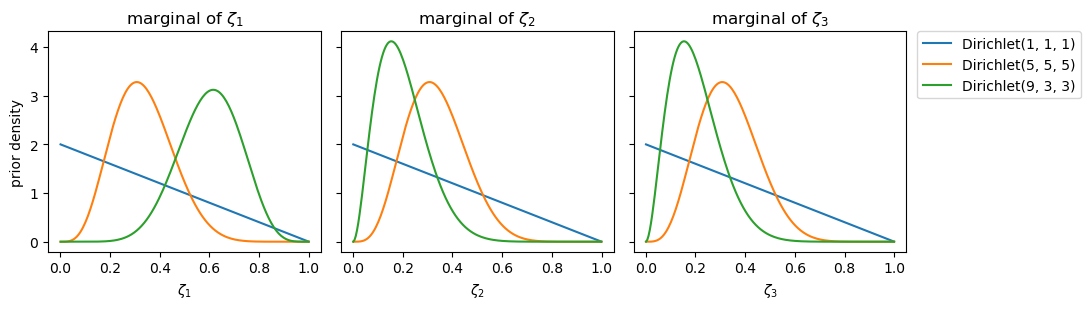

In [16]:
def beta_marginal(alpha):
    alpha = np.asarray(alpha)
    a0 = alpha.sum()
    return [(a, a0 - a) for a in alpha]

prior_examples = {
    "Dirichlet(1, 1, 1)": np.array([1.0, 1.0, 1.0]),
    "Dirichlet(5, 5, 5)": np.array([5.0, 5.0, 5.0]),
    "Dirichlet(9, 3, 3)": np.array([9.0, 3.0, 3.0]),
}

D = 3
xs = np.linspace(0.001, 0.999, 200)
fig, axes = plt.subplots(1, D, figsize=(11, 3.2), sharey=True)
for j, ax in enumerate(axes):
    for name, alpha in prior_examples.items():
        a, b = beta_marginal(alpha)[j]
        ax.plot(xs, stats.beta.pdf(xs, a, b), label=name)
    ax.set_title(f"marginal of $\\zeta_{{{j+1}}}$")
    ax.set_xlabel(f"$\\zeta_{{{j+1}}}$")
axes[0].set_ylabel("prior density")
axes[-1].legend(bbox_to_anchor=(1.04, 1), loc="upper left", borderaxespad=0)
fig.tight_layout();

Each panel shows the prior density of one element of $\zeta$. The blue $\text{Dirichlet}(1, 1, 1)$ line is *straight*, not flat, and that surprises a lot of people. The reason: $\text{Dirichlet}(1, 1, 1)$ is uniform on the 2-simplex (the triangle in 3D), but the marginal of any single component is $\text{Beta}(1, 2)$, which has density $f(x) = 2(1 - x)$. Geometrically, there is more room on the simplex when one component is small than when it is large, so the marginal of each $\zeta_i$ piles up near 0 even though the joint is flat. "Uniform on the simplex" therefore does *not* mean "each step is equally likely to be any size in $[0, 1]$."

Increasing the total concentration ($\text{Dirichlet}(5, 5, 5)$) tightens each marginal around $1/D$ (the linear-trend point). The elicited shape $\text{Dirichlet}(9, 3, 3)$ pulls the first step's marginal toward larger values and the others toward smaller ones.

One subtlety the paper highlights: the simplex components are *negatively correlated* by construction, with

$$
\text{Cor}(\zeta_i, \zeta_j) \;=\; -\sqrt{\frac{w_i w_j}{(1 - w_i)(1 - w_j)}}.
$$

Marginal plots ignore this dependence, so when communicating priors it is still worth eyeballing joint draws.

Fit the model with a strong $(5, 1, 1)$ prior that favours a large first step and see how the data and prior combine:

In [17]:
priors = {
    "mo(income)": {
        "simplex": bmb.Prior("Dirichlet", a=np.array([5.0, 1.0, 1.0])),
    }
}
model_prior = bmb.Model("ls ~ mo(income)", data, priors=priors)
idata_prior = model_prior.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False
)
az.summary(idata_prior, var_names=["mo(income)_simplex"])

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, mo(income)_simplex, mo(income)_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mo(income)_simplex[20_to_40],0.6421,0.0191,0.61,0.67,4253,2727,1.00,0.00029,0.00021
mo(income)_simplex[40_to_100],0.2105,0.0228,0.17,0.25,3674,2595,1.00,0.00037,0.00026
mo(income)_simplex[greater_100],0.1474,0.02,0.12,0.18,3902,2675,1.00,0.00032,0.00023


With this strong prior the simplex pulls toward the first-step-dominates corner. The posterior still recovers the data-driven shape closely because we have 400 observations. With less data the prior would dominate more visibly. A useful workflow is to fit with both the default and a more informative prior and compare; if the conclusions move, your data is not pinning down the shape on its own.

## 5. Sharing a simplex via `id=` (conditional monotonicity)

Sometimes two `mo()` terms involve predictors that share the same monotonic shape. The classic case is a `mo(x) * z` interaction where you want the shape of the monotonic effect on `x` to be the same across levels of `z`. This is *conditional monotonicity* in the sense of Bürkner and Charpentier's Proposition 1: if the same simplex is shared across all terms involving $x$, then $\eta$ is monotonic in $x$ conditional on any combination of the other predictors. If each term gets its own simplex, conditional monotonicity is not guaranteed.

To illustrate, suppose two ordered predictors both follow the same cumulative-shape pattern.

In [18]:
shape = np.array([0.0, 30.0, 40.0, 45.0])
income1 = pd.Categorical(rng.choice(levels, 500), categories=levels, ordered=True)
income2 = pd.Categorical(rng.choice(levels, 500), categories=levels, ordered=True)
mu_id = 5.0 + shape[income1.codes] + shape[income2.codes]
y_id = mu_id + rng.normal(0, 5, 500)
data_id = pd.DataFrame({"y": y_id, "income1": income1, "income2": income2})

model_id = bmb.Model(
    "y ~ mo(income1, id='shape') + mo(income2, id='shape')",
    data_id,
)
model_id

       Formula: y ~ mo(income1, id='shape') + mo(income2, id='shape')
        Family: gaussian
          Link: mu = identity
  Observations: 500
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 62.755, sigma: 61.7903)
        
        Monotonic effects
            mo(income1, id='shape')
                simplex ~ Dirichlet(a: [1. 1. 1.])
                slope ~ Normal(mu: 0.0, sigma: 20.5968)
            mo(income2, id='shape')
                simplex ~ Dirichlet(a: [1. 1. 1.])
                slope ~ Normal(mu: 0.0, sigma: 20.5968)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 24.7161)

In [19]:
idata_id = model_id.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)
az.summary(
    idata_id,
    var_names=[
        "Intercept",
        "mo(income1, id='shape')_slope",
        "mo(income2, id='shape')_slope",
        "simplex_shape",
    ],
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, simplex_shape, mo(income1, id='shape')_slope, mo(income2, id='shape')_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,4.44,0.65,3.4,5.4,2468,2330,1.00,0.013,0.0093
"mo(income1, id='shape')_slope",14.886,0.21,15,15,2875,2797,1.00,0.0039,0.0027
"mo(income2, id='shape')_slope",15.044,0.223,15,15,2889,2577,1.00,0.0042,0.003
simplex_shape[20_to_40],0.6629,0.0096,0.65,0.68,3955,3135,1.00,0.00015,0.00011
simplex_shape[40_to_100],0.236,0.0107,0.22,0.25,4606,3257,1.00,0.00016,0.00012
simplex_shape[greater_100],0.1011,0.0098,0.086,0.12,2758,2192,1.00,0.00019,0.00014


Only one Dirichlet variable, `simplex_shape`, was sampled. Both terms reuse it. Each term still has its own slope, so the *magnitude* of the monotonic effect can differ across predictors even though the *shape* is shared.

How much does the sharing buy us when the assumption holds? Compare against the unshared alternative.

In [20]:
# Compare against numeric and categorical baselines as well.
data_id_aux = data_id.copy()
data_id_aux["income1_code"] = data_id_aux["income1"].cat.codes.astype(float)
data_id_aux["income2_code"] = data_id_aux["income2"].cat.codes.astype(float)

model_id_num = bmb.Model(
    "y ~ income1_code + income2_code", data_id_aux
)
idata_id_num = model_id_num.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

model_id_cat = bmb.Model("y ~ C(income1) + C(income2)", data_id_aux)
idata_id_cat = model_id_cat.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

model_no_id = bmb.Model(
    "y ~ mo(income1) + mo(income2)",
    data_id,
)
idata_no_id = model_no_id.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

az.compare(
    {
        "numeric": idata_id_num,
        "categorical": idata_id_cat,
        "monotonic (unshared)": idata_no_id,
        "monotonic (shared id='shape')": idata_id,
    }
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, income1_code, income2_code]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, mo(income1)_simplex, mo(income1)_slope, mo(income2)_simplex, mo(income2)_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,rank,elpd,p,elpd_diff,weight,se,dse,warning
monotonic (shared id='shape'),0,-1550.0,5.9,0.0,1.0,16.0,0.00,False
categorical,1,-1550.0,7.9,-2.0,0.0,16.0,0.85,False
monotonic (unshared),2,-1550.0,8.0,-2.0,0.0,16.0,0.86,False
numeric,3,-1880.0,3.5,-330.0,0.0,14.0,17.00,False


Four models in this comparison: a numeric encoding of both ordered predictors, a fully categorical encoding, an unshared mo (each `mo()` gets its own Dirichlet), and the shared-id mo where one simplex is reused across both `mo()` calls. The two mo variants score similarly on `elpd_loo` (the unshared model can mimic the shared shape if the data are informative), but the `p_loo` column shows the shared model uses fewer effective parameters. The numeric encoding scores the worst because it forces both bracket effects to be linear. The categorical encoding is competitive but spends more parameters than either mo variant. When the shared-shape assumption actually holds, sharing the simplex gives tighter posteriors with no loss of fit.

## 6. Interactions

`mo()` interacts cleanly with continuous and categorical predictors. For illustration, suppose the bracket-by-bracket effect of `income` on `ls` is amplified for participants who report a high external stressor `x`.

In [21]:
x = rng.normal(size=n)
mu_int = 5.0 + shape[income.codes] + 4.0 * x + 0.15 * shape[income.codes] * x
y_int_data = mu_int + rng.normal(0, 3, n)
data_int = pd.DataFrame(
    {"y": y_int_data, "income": income, "x": x}
)

model_int = bmb.Model("y ~ mo(income) * x", data_int)
model_int

       Formula: y ~ mo(income) * x
        Family: gaussian
          Link: mu = identity
  Observations: 400
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 33.6881, sigma: 51.315)
            x ~ Normal(mu: 0.0, sigma: 51.9377)
        
        Monotonic effects
            mo(income)
                simplex ~ Dirichlet(a: [1. 1. 1.])
                slope ~ Normal(mu: 0.0, sigma: 17.1049)
            mo(income):x
                slope ~ Normal(mu: 0.0, sigma: 1.0)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 20.5259)

In [22]:
idata_int = model_int.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)
az.summary(
    idata_int,
    var_names=["Intercept", "mo(income)_slope", "x", "mo(income):x_slope"],
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, x, mo(income)_simplex, mo(income)_slope, mo(income):x_simplex_0, mo(income):x_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,4.83,0.298,4.3,5.3,2772,2385,1.00,0.0057,0.004
mo(income)_slope,15.003,0.14,15,15,2214,2337,1.00,0.003,0.0022
x,3.95,0.298,3.5,4.4,2697,2695,1.00,0.0058,0.0041
mo(income):x_slope,2.109,0.131,1.9,2.3,2351,2678,1.00,0.0027,0.0018


The `mo(income):x_slope` posterior is positive, confirming the interaction. We can use Bambi's `plot_predictions` to visualize how the effect of `income` varies with `x`.

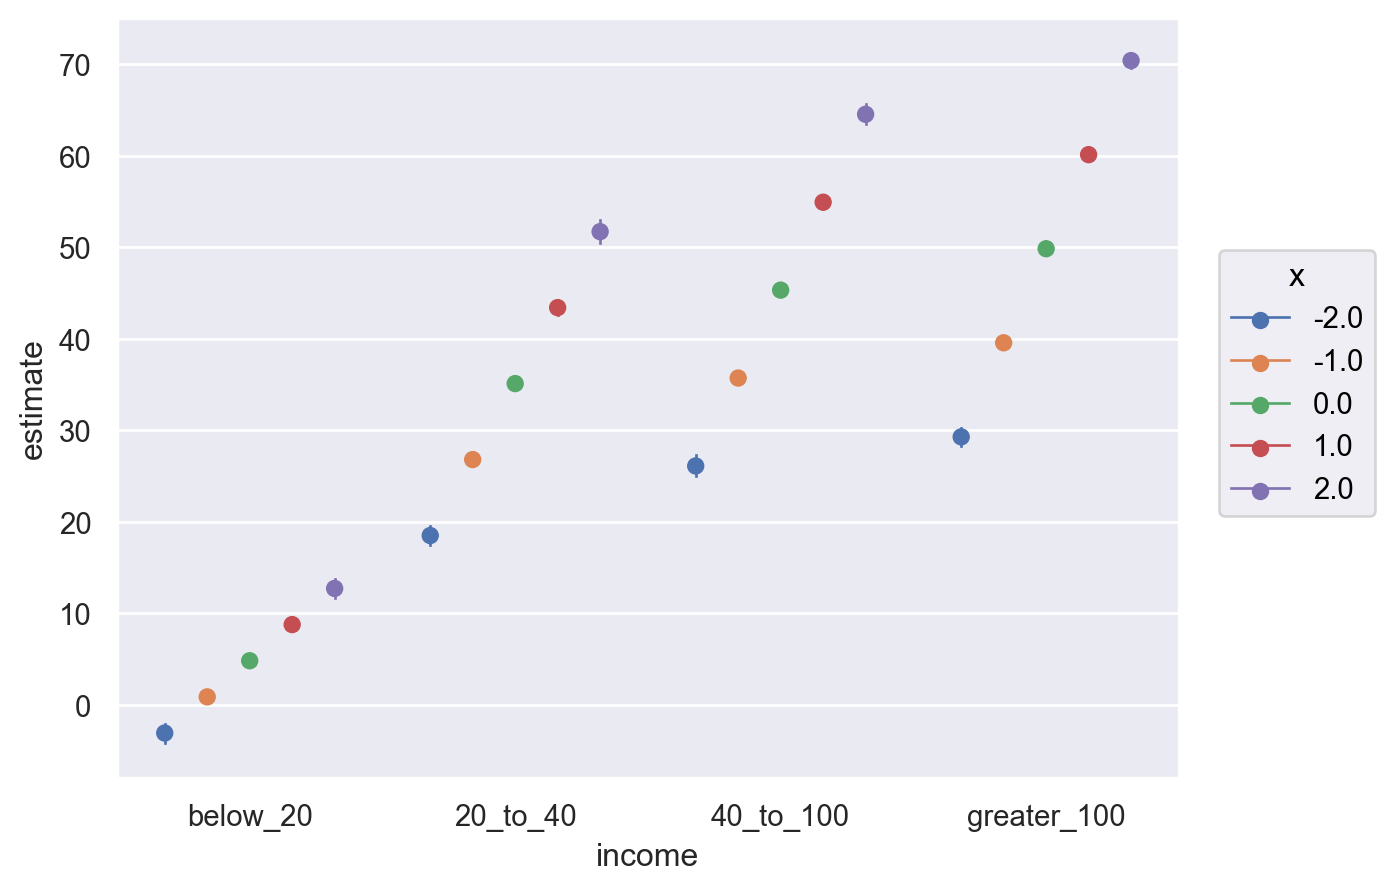

In [23]:
plot_predictions(
    model_int,
    idata_int,
    conditional={"income": levels, "x": np.linspace(-2, 2, 5)},
)

Each line corresponds to a value of `x`. At the highest value of `x`, the slope through the brackets is steeper than at the lowest, because the interaction amplifies the per-bracket effect.

Sanity-check the interaction term with LOO: a no-interaction model should fit worse here because the data were simulated with an interaction.

In [24]:
# Compare against numeric and categorical encodings as well.
data_int_aux = data_int.copy()
data_int_aux["income_code"] = data_int_aux["income"].cat.codes.astype(float)

model_int_num = bmb.Model("y ~ income_code * x", data_int_aux)
idata_int_num = model_int_num.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

model_int_cat = bmb.Model("y ~ C(income) * x", data_int_aux)
idata_int_cat = model_int_cat.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

model_no_int = bmb.Model("y ~ mo(income) + x", data_int)
idata_no_int = model_no_int.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

az.compare(
    {
        "numeric * x": idata_int_num,
        "categorical * x": idata_int_cat,
        "mo(income) + x (no interaction)": idata_no_int,
        "mo(income) * x (with interaction)": idata_int,
    }
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, income_code, x, income_code:x]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, x, mo(income)_simplex, mo(income)_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,rank,elpd,p,elpd_diff,weight,se,dse,warning
mo(income) * x (with interaction),0,-1020.0,8.7,0.0,0.00,16.0,0.00,False
categorical * x,1,-1020.0,8.8,-0.1,0.97,16.0,0.35,False
mo(income) + x (no interaction),2,-1120.0,6.8,-110.0,0.03,16.0,16.00,False
numeric * x,3,-1360.0,4.0,-340.0,0.00,9.9,16.00,False


Four models: a fully numeric `income_code * x` interaction, a fully categorical `C(income) * x` interaction, a mo additive model with no interaction, and the mo with-interaction model. The mo with-interaction wins on `elpd_loo` (the data really do contain the interaction we simulated) and uses fewer effective parameters than the categorical analogue. The numeric variant lags clearly: forcing the income effect to be linear leaves the interaction with the wrong shape to capture.

Following Proposition 1, note that the mo interaction model uses *independent* simplices for the main `mo(income)` term and the `mo(income):x` interaction by default. If you wanted to enforce conditional monotonicity (same shape across all values of `x`), you would tag both occurrences with the same `id=`.

## 7. Group-specific monotonic effects, `(mo(x) | g)`

When the monotonic slope varies by group, write it like any other group-specific term. The simplex is shared across groups (this matches brms), but each group gets its own slope offset $r_g$ with a hierarchical Normal/HalfNormal prior:

$$
r_g \sim \mathcal{N}(0, \sigma_g), \qquad \sigma_g \sim \text{HalfNormal}.
$$

The total slope for group $g$ is $b + r_g$, where $b$ is the population-level slope.

In [25]:
g_levels = [f"g{i}" for i in range(1, 6)]
slope_per_group = {"g1": 1.0, "g2": 1.3, "g3": 0.7, "g4": 1.5, "g5": 0.5}

n_gs = 800
group = pd.Categorical(rng.choice(g_levels, n_gs), categories=g_levels)
income_gs = pd.Categorical(
    rng.choice(levels, n_gs), categories=levels, ordered=True
)
g_mult = np.array([slope_per_group[g] for g in group])
mu_gs = 5.0 + shape[income_gs.codes] * g_mult
y_gs = mu_gs + rng.normal(0, 3, n_gs)
data_gs = pd.DataFrame({"y": y_gs, "income": income_gs, "g": group})

model_gs = bmb.Model(
    "y ~ mo(income, id='inc') + (mo(income, id='inc') | g)",
    data_gs,
)
model_gs

       Formula: y ~ mo(income, id='inc') + (mo(income, id='inc') | g)
        Family: gaussian
          Link: mu = identity
  Observations: 800
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 34.5935, sigma: 55.0003)
        
        Group-level effects
            1|g ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 55.0003))
        
        Monotonic effects
            mo(income, id='inc')
                simplex ~ Dirichlet(a: [1. 1. 1.])
                slope ~ Normal(mu: 0.0, sigma: 18.3334)
            mo(income, id='inc')|g
                simplex ~ Dirichlet(a: [1. 1. 1.])
                slope ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 1.0))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 22.0001)

We use `id='inc'` to share the simplex between the population-level term and the group-specific term. This matches the default brms behavior: groups can differ in the magnitude of the monotonic effect, but they share its shape.

In [26]:
idata_gs = model_gs.fit(
    draws=1000,
    tune=1000,
    chains=4,
    target_accept=0.95,
    random_seed=1234,
    progressbar=False,
    idata_kwargs={"log_likelihood": True},
)
az.summary(
    idata_gs,
    var_names=[
        "Intercept",
        "mo(income, id='inc')_slope",
        "mo(income, id='inc')|g_sigma",
        "mo(income, id='inc')|g",
        "simplex_inc",
    ],
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, simplex_inc, mo(income, id='inc')_slope, mo(income, id='inc')|g_sigma, mo(income, id='inc')|g_offset, 1|g_sigma, 1|g_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 18 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,5.05,0.33,4.6,5.5,2411,2407,1.00,0.0078,0.015
"mo(income, id='inc')_slope",14.89,1.51,12,17,1065,1504,1.00,0.046,0.034
"mo(income, id='inc')|g_sigma",3.36,0.47,2.7,4.2,2377,2466,1.00,0.0096,0.0071
"mo(income, id='inc')|g[g1]",0.1,1.51,-2.3,2.5,1080,1524,1.00,0.046,0.034
"mo(income, id='inc')|g[g2]",4.54,1.51,2.1,6.9,1068,1512,1.00,0.046,0.034
"mo(income, id='inc')|g[g3]",-4.55,1.51,-7,-2.2,1081,1457,1.00,0.046,0.033
"mo(income, id='inc')|g[g4]",7.62,1.51,5.2,10,1059,1532,1.00,0.046,0.034
"mo(income, id='inc')|g[g5]",-7.42,1.51,-9.8,-5,1051,1468,1.00,0.046,0.034
simplex_inc[20_to_40],0.6657,0.0057,0.66,0.67,4392,2831,1.00,8.6e-05,6.1e-05
simplex_inc[40_to_100],0.2268,0.0068,0.22,0.24,4543,2811,1.00,0.0001,7.1e-05


Per-group slope offsets, plotted on a forest:

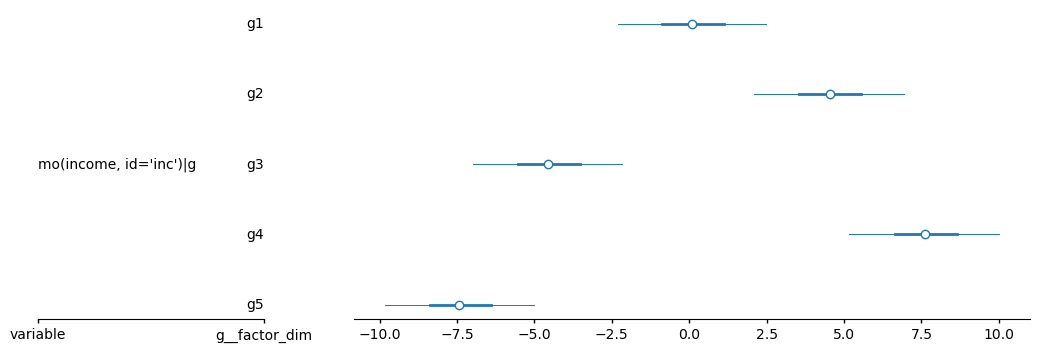

In [27]:
az.plot_forest(
    idata_gs,
    var_names=["mo(income, id='inc')|g"],
    combined=True,
);

The total slope for each group is the population slope plus its offset. We can extract that posterior and compare it against the truth.

In [28]:
post_gs = idata_gs.posterior
b_pop = post_gs["mo(income, id='inc')_slope"]
r_g = post_gs["mo(income, id='inc')|g"]
totals = (b_pop + r_g).mean(("chain", "draw")).to_numpy()
truth = np.array([slope_per_group[g] * 15 for g in g_levels])
pd.DataFrame(
    {
        "group": g_levels,
        "fitted_total_slope": totals.round(2),
        "true_total_slope": truth,
    }
)

,group,fitted_total_slope,true_total_slope
0,g1,15.00,15.0
1,g2,19.43,19.5
2,g3,10.34,10.5
3,g4,22.51,22.5
4,g5,7.47,7.5


Is the group-specific structure worth its complexity? Compare against the pooled model that only fits a population-level monotonic effect.

In [29]:
# Compare against numeric and categorical group-specific alternatives as well.
data_gs_aux = data_gs.copy()
data_gs_aux["income_code"] = data_gs_aux["income"].cat.codes.astype(float)

model_gs_num = bmb.Model(
    "y ~ income_code + (income_code | g)", data_gs_aux
)
idata_gs_num = model_gs_num.fit(
    draws=1000, tune=1000, chains=4, target_accept=0.95,
    random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

model_gs_cat = bmb.Model("y ~ C(income) + (C(income) | g)", data_gs_aux)
idata_gs_cat = model_gs_cat.fit(
    draws=1000, tune=1000, chains=4, target_accept=0.95,
    random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

model_gs_pooled = bmb.Model("y ~ mo(income)", data_gs)
idata_gs_pooled = model_gs_pooled.fit(
    draws=1000, tune=1000, chains=4, random_seed=1234, progressbar=False,
    idata_kwargs={"log_likelihood": True},
)

az.compare(
    {
        "numeric (group-specific)": idata_gs_num,
        "categorical (group-specific)": idata_gs_cat,
        "monotonic (pooled)": idata_gs_pooled,
        "monotonic (group-specific)": idata_gs,
    }
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, income_code, 1|g_sigma, 1|g_offset, income_code|g_sigma, income_code|g_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.


There were 5 divergences after tuning. Increase `target_accept` or reparameterize.


...

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [sigma, Intercept, mo(income)_simplex, mo(income)_slope]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


,rank,elpd,p,elpd_diff,weight,se,dse,warning
monotonic (group-specific),0,-2010.0,10.4,0.0,0.65,22.0,0.0,False
categorical (group-specific),1,-2010.0,18.3,-2.0,0.35,21.0,3.4,False
numeric (group-specific),2,-2750.0,9.8,-740.0,0.00,15.0,24.0,False
monotonic (pooled),3,-3180.0,4.5,-1170.0,0.00,16.0,26.0,False


Four models again: a numeric `(income_code | g)` group-specific slope, a categorical `(C(income) | g)` group-specific intercepts, a pooled mo (no group structure), and the group-specific mo. The group-specific mo wins decisively on `elpd_loo`, which is expected given how different the per-group slopes are in the simulated data. The categorical group-specific is in the same ballpark but spends many more parameters; the pooled mo and numeric variants both lag because they cannot represent the per-group differences (pooled) or the non-linear shape (numeric).

## 8. When `mo()` is not the right tool

Monotonic terms shine in a clear band of problems. They are less appropriate in a handful of situations the paper calls out explicitly.

* **Monotonicity has to be defensible.** Bürkner and Charpentier are blunt: "The assumption of monotonicity is critical and needs to be theoretically justified and/or statistically investigated." Their recommended workflow is to fit both with and without the monotonicity constraint and compare (LOO, model weights).
* **Very large $K$.** Strong negative correlation among the simplex components degrades HMC mixing. The paper reports max-tree-depth exhaustion with $K = 50$ levels. For very-high-cardinality ordinal predictors, monotonic splines or other smoothers tend to be a better fit.
* **Latent rather than manifest predictor.** `mo()` treats the predictor as observed without measurement error. If you believe the ordinal predictor is a coarsening of an underlying latent continuous variable measured with noise, use a latent-variable model instead.
* **You want smoothness.** $\eta$ as a function of the codes is piecewise linear, not differentiable at the levels. Priors on $b$ or $\zeta$ do not make it smoother. If a smooth response is the explicit goal, splines via `bs()` are a better fit.
* **You need variable selection over `mo()` terms.** The paper notes the absence of a principled variable-selection method for monotonic terms as an open problem; standard sparsity priors (horseshoe and friends) do not directly apply to the slope $b$ in isolation.

## Summary

`mo()` gives you a principled way to model ordered predictors with unequal spacing using just two parameters per term. It composes with the rest of Bambi's machinery: distributional components, interactions, group-specific effects, custom priors, and shared simplices for conditional monotonicity.

Where `mo()` reliably beats the fully categorical alternative is *not* sampling speed (for typical $K$ those are roughly comparable), but in the following four areas:

* **Posterior tightness on the same data.** The monotonicity constraint   *is* information. With identical data, the credible bands on bracket   effects are visibly narrower for `mo()` than for `C(...)`.
* **Out-of-sample predictive accuracy when monotonicity actually   holds.** This shows up as lower `p_loo` in the LOO comparisons above.   `mo()` spends fewer effective parameters to recover the same   bracket-level fit.
* **Interpretability of $b$ and $\zeta_i$.** A single slope $b$   carries direction and total magnitude, and the simplex $\zeta_i$   decomposes that into a story about *which* steps matter. With $K - 1$   free dummies you have to reconstruct that story yourself.
* **Robustness when extrapolating to unseen levels in an ordered   scale.** If a new category sits between two seen ones on the scale,   `mo()` interpolates naturally via the cumulative-sum form. The   categorical encoding has no notion of order, so an unseen level is   simply unestimable.

Reach for `mo()` whenever an ordered predictor has more than three or four levels and you have no strong reason to assume the per-level increments are equal. Compare with both the linear and the unconstrained categorical fit to make sure the constraint is actually paying for itself.

## References

* Bürkner, P.-C., and Charpentier, E. (2020). Modelling monotonic effects of ordinal predictors in Bayesian regression models. *British Journal of Mathematical and Statistical Psychology*, 73(3), 420-451. [doi:10.1111/bmsp.12195](https://doi.org/10.1111/bmsp.12195). [Open-access PDF](https://paulbuerkner.com/publications/pdf/2020__Buerkner_Charpentier__British_Journal_of_Mathematical_and_Statistical_Psychology.pdf).
* brms `mo()` reference: [paulbuerkner.com/brms/reference/mo.html](https://paulbuerkner.com/brms/reference/mo.html)

In [30]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Fri, 22 May 2026

Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.13.0

arviz     : 1.1.0
bambi     : 0.18.0
matplotlib: 3.10.9
numpy     : 2.4.6
pandas    : 3.0.3
scipy     : 1.17.1

Watermark: 2.6.0

